# 4. An Introduction to Entanglement

We can be glad that there is more to quantum mechanics than just single qubits or systems of "multiple single" qubits. In this notebook, you will learn about the concept that makes multi-qubit systems much more complex (and powerful) than just the sum of their parts: **entanglement**.

Entanglement arises from the interactions of qubits with each other. Unfortunately, once multiple qubits interact and become entangled, they can no longer be visualized on the standard Bloch sphere, which describes individual qubits. Therefore, we continue with the **Dimensional Circle Notation (DCN)** visualization.

In this notebook, you will discover:
1.  How multi-qubit systems are represented mathematically and in DCN.
2.  How qubits interact via the **CNOT** gate.
3.  How the **Bell States**—the most fundamental entangled states—are created.
4.  What happens when measuring entangled systems.

## 4.1. Representing Multi-Qubit Systems

When we move from one qubit to two, the complexity of the system grows. Mathematically, we describe a composite system of two independent qubits using the **tensor product** ($\otimes$). If qubit $A$ is in state $|\psi_A\rangle$ and qubit $B$ is in state $|\psi_B\rangle$, the combined state is:

$$
|\psi_{AB}\rangle = |\psi_A\rangle \otimes |\psi_B\rangle
$$

For the computational basis states, this gives us four possibilities:

* $|0\rangle \otimes |0\rangle = |00\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix} \otimes \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}$
* $|0\rangle \otimes |1\rangle = |01\rangle$
* $|1\rangle \otimes |0\rangle = |10\rangle$
* $|1\rangle \otimes |1\rangle = |11\rangle$

A general two-qubit state is a **superposition** of all four basis states:

$$
|\psi\rangle = \alpha_{00}|00\rangle + \alpha_{01}|01\rangle + \alpha_{10}|10\rangle + \alpha_{11}|11\rangle
$$

subject to the normalization condition $\sum |\alpha_{ij}|^2 = 1$. Note that in general, there are no $|\psi_A\rangle$ and $|\psi_B\rangle$ such that

$$|\psi\rangle = |\psi_A\rangle \otimes |\psi_B\rangle.$$

If there are, the state $|\psi\rangle$ is called separable. If there aren't, the state is called entangled.

### Visualization in DCN
In Dimensional Circle Notation (DCN), we visualize this by giving each qubit an axis in space. The idea to utilize axes to visualize explicit amplitude of basis states is originally from Ref. [1]. For a 2-qubit system, we have $2^2 = 4$ circles. Below, the product state $$ \ket{\psi}=\left(\frac{1}{\sqrt{3}}\ket{0}+\frac{\sqrt{2}}{\sqrt{3}}e^{-i\pi/4}\ket{1}\right)\otimes\left(\frac{\sqrt{3}}{2}\ket{0}-\frac{1}{2}\ket{1}\right)=\frac{1}{2}\ket{00}-\frac{1}{\sqrt{12}}\ket{01}+\frac{1}{\sqrt{2}}e^{-i\pi/4}\ket{10}+\frac{1}{\sqrt{6}}e^{3i\pi/4}\ket{11}$$

is shown. Keep in mind that this state, because it is a product state, is not entangled.

<img src="images/dcn_intro.png" width="1000">


We can see this separability also in a symmetry axes along the axis of qubit 1 or 2, where the circles and lines are the same, apart from a complex ratio ($r_1=\sqrt{2}e^{-i\pi/4}$ along the axis of qubit 1 and $r_2=-\frac{1}{\sqrt{3}}$ along the axis of qubit 2). An entangled state will be asymmetric. More on this can be found in Ref. [2].

Single-qubit operations in multi-qubit systems work the same way as in one-qubit systems, except that they work along the axis of the qubit they are assigned to and work on each pair of states along that axis. Below is the $Z$-gate to illustrate this.

<img src="images/dcn_intro_z.png" width="1000">

Below, it is shown how a quantumcircuit using two qubits can be constructed and statevectors visualized with DCN. Feel free to perform various gate actions to see what happens.

State vector after circuit:
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


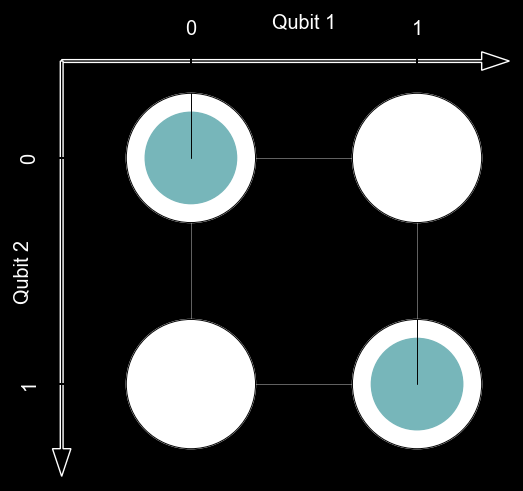

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
# Import custom education package for visualization
from qc_education_package import Simulator, DimensionalCircleNotation
import matplotlib.pyplot as plt

# Initialize a Qiskit QuantumCircuit with 2 qubits
qc = QuantumCircuit(2)

# Step 1: Hadamard on Qubit 0
# In Qiskit, qubit 0 is the rightmost in the bitstring (Little Endian).
qc.h(0)

# Step 2: CNOT with Control 0, Target 1
qc.cx(0, 1)

# Simulate the circuit to get the statevector
# Statevector.from_instruction() runs the circuit mathematically
sv = Statevector.from_instruction(qc)

print("State vector after circuit:")
print(sv.data)

# Visualize using DCN
DimensionalCircleNotation.from_qiskit(sv).show()

Note how we cannot see a symmetry axis along a qubit in this state, showing that it is entangled.

## 4.2. Interaction: The CNOT Gate

Entanglement arises when qubits interact. The most fundamental 2-qubit gate is the **Controlled-NOT (CNOT)** or $CX$ gate. It acts on two qubits:
* **Control Qubit:** Usually the first qubit (leftmost).
* **Target Qubit:** Usually the second qubit (rightmost).

The CNOT gate is usually given the indices CNOT$_{xy}$, where $x$ is the control qubit and $y$ is the target qubit.

**Action:** If the *control* qubit is in state $|1\rangle$, the *target* qubit is flipped (Applying an $X$ gate). If the control is $|0\rangle$, nothing happens to the target.

Mathematically, the CNOT$_{12}$ matrix is:

$$
CNOT_{12} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}
$$

### Visualizing CNOT
In DCN, the CNOT gate can be understood as swapping specific states. Since it flips the target (second bit) only if the control (first bit) is 1, e.g. the CNOT$_12$ gate, swaps the amplitudes of $|10\rangle$ and $|11\rangle$, while leaving $|00\rangle$ and $|01\rangle$ unchanged. The CNOT gate acts along the axis of the target qubit if the control qubit is in the state 1:

<img src="images/dcn_intro_cnot.png" width="1000">

<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
The CNOT gate, together with the rotations on the Bloch sphere, form a universal gate set for arbitrary sizes of qubit systems, allowing for universal quantum computation. Therefore, in a sense, they are all we need.
</div>

## 4.3. The Bell States

The Bell states are four specific, maximally entangled quantum states of two qubits. They are the building blocks of advanced protocols like quantum teleportation and superdense coding.

### The First Bell State: $|\Phi^+\rangle$
To create the first Bell state, we start with the ground state $|00\rangle$.

1.  **Hadamard (H) on Control:** We apply a Hadamard gate to the first qubit. This puts it into a superposition, creating the state:
    $$
    |00\rangle \xrightarrow{H_1 = H \otimes I} \frac{|0\rangle + |1\rangle}{\sqrt{2}} \otimes |0\rangle = \frac{|00\rangle + |10\rangle}{\sqrt{2}}
    $$

2.  **CNOT$_{12}$ (Control qubit 1, Target qubit 2):** We uses the first qubit to control the second.
    * The part of the superposition that is $|00\rangle$ remains $|00\rangle$ (Control is 0).
    * The part of the superposition that is $|10\rangle$ becomes $|11\rangle$ (Control is 1, so Target flips from 0 to 1).

    $$
    \frac{|00\rangle + |10\rangle}{\sqrt{2}} \xrightarrow{CNOT_{12}} \frac{|00\rangle + |11\rangle}{\sqrt{2}} = |\Phi^+\rangle
    $$

Notice that in this state, the qubits are perfectly correlated. If we measure "0" on the first qubit, we are guaranteed to measure "0" on the second. If we measure "1" on the first, we will find "1" on the second.

> **[Insert your image of the Bell State in DCN here]**

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
<strong>Your Task:</strong> Prove that the Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ is an <strong>entangled state</strong>. To do this, assume the state is separable (a product state) and mathematically demonstrate that this assumption leads to a contradiction.
</div>
<p>
<details style="background-color: #4c3575; color: #ffffff; border: 1px solid #ccc; padding: 10px; border-radius: 5px;">
  <summary style="cursor: pointer; color: #ffffff;">Solution (click to expand)</summary>
  <div style="background-color: #4c3575; color: #ffffff; padding: 10px; margin-top: 10px; border-left: 3px solid #ffffff;">
    <p>To determine if $|\Phi^+\rangle$ is entangled, we assume it is a separable state (a product state) of two qubits. A general product state can be written as:</p>

$$|\psi\rangle = (a|0\rangle + b|1\rangle) \otimes (c|0\rangle + d|1\rangle)$$

<p>Expanding this tensor product gives:</p>

$$|\psi\rangle = ac|00\rangle + ad|01\rangle + bc|10\rangle + bd|11\rangle$$

<p>We equate this general form to the target Bell state $|\Phi^+\rangle$:</p>

$$ac|00\rangle + ad|01\rangle + bc|10\rangle + bd|11\rangle = \frac{1}{\sqrt{2}}|00\rangle + 0|01\rangle + 0|10\rangle + \frac{1}{\sqrt{2}}|11\rangle$$

<p>Comparing the coefficients for each basis vector yields the following system of equations:</p>
<ol>
    <li>$ac = \frac{1}{\sqrt{2}}$</li>
    <li>$ad = 0$</li>
    <li>$bc = 0$</li>
    <li>$bd = \frac{1}{\sqrt{2}}$</li>
</ol>

<p><strong>Logical Analysis:</strong></p>
<ul>
    <li>From equation (2) ($ad = 0$), either $a=0$ or $d=0$.</li>
    <li><strong>Case 1:</strong> If $a=0$, then equation (1) becomes $0 \cdot c = \frac{1}{\sqrt{2}}$, which is a contradiction ($0 \neq \frac{1}{\sqrt{2}}$).</li>
    <li><strong>Case 2:</strong> If $d=0$, then equation (4) becomes $b \cdot 0 = \frac{1}{\sqrt{2}}$, which is also a contradiction.</li>
</ul>

<p>Since assuming the state is separable leads to a mathematical contradiction, $|\Phi^+\rangle$ cannot be written as a product state. Therefore, <strong>$|\Phi^+\rangle$ is entangled.</strong></p>
  </div>
</details>

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
<strong>Your Task:</strong> Derive the general condition for entanglement. Prove that an arbitrary two-qubit state $|\psi\rangle = a_{00}|00\rangle + a_{01}|01\rangle + a_{10}|10\rangle + a_{11}|11\rangle$ is <strong>separable</strong> (not entangled) if and only if the coefficients satisfy the condition:
<br><br>
<center>$$a_{00}a_{11} = a_{01}a_{10}$$</center>
<br>
<em>Hint: Start by assuming the state is separable, meaning it can be written as the tensor product of two single-qubit states $(\alpha|0\rangle + \beta|1\rangle) \otimes (\gamma|0\rangle + \delta|1\rangle)$.</em>
</div>

<p>
<details style="background-color: #4c3575; color: #ffffff; border: 1px solid #ccc; padding: 10px; border-radius: 5px;">
  <summary style="cursor: pointer; color: #ffffff;">Solution (click to expand)</summary>
  <div style="background-color: #4c3575; color: #ffffff; padding: 10px; margin-top: 10px; border-left: 3px solid #ffffff;">
    <p>To find the condition for separability, we assume $|\psi\rangle$ is a product state. This means it must be possible to write it as:</p>

$$|\psi\rangle = (\alpha|0\rangle + \beta|1\rangle) \otimes (\gamma|0\rangle + \delta|1\rangle)$$

<p>Expanding the tensor product, we get:</p>

$$|\psi\rangle = \alpha\gamma|00\rangle + \alpha\delta|01\rangle + \beta\gamma|10\rangle + \beta\delta|11\rangle$$

<p>We now match these coefficients to the general coefficients $a_{ij}$ given in the problem statement:</p>

<ol>
    <li>$a_{00} = \alpha\gamma$</li>
    <li>$a_{01} = \alpha\delta$</li>
    <li>$a_{10} = \beta\gamma$</li>
    <li>$a_{11} = \beta\delta$</li>
</ol>

<p>Now, let's look at the product $a_{00}a_{11}$:</p>

$$a_{00}a_{11} = (\alpha\gamma)(\beta\delta) = \alpha\beta\gamma\delta$$

<p>Next, let's look at the product $a_{01}a_{10}$:</p>

$$a_{01}a_{10} = (\alpha\delta)(\beta\gamma) = \alpha\beta\gamma\delta$$

<p><strong>Conclusion:</strong></p>
<p>Since both products equal $\alpha\beta\gamma\delta$, we have shown that for any separable state, the equality must hold:</p>

$$a_{00}a_{11} = a_{01}a_{10}$$

<p>Conversely, if $a_{00}a_{11} \neq a_{01}a_{10}$, the state <strong>cannot</strong> be written as a product state and is therefore <strong>entangled</strong>.</p>
  </div>
</details>

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Challenge: create the bell state $\ket{\Psi^-}=\frac{1}{\sqrt{2}}\ket{01}-\frac{1}{\sqrt{2}}\ket{10}$
</div>

In [2]:
from qc_education_package import ChallengeDCNViewer

viewer = ChallengeDCNViewer(
    num_qubits=2,
    initial_state=[1, 0,0,0],
    target_state=[0,1,-1, 0]
)

viewer.display()

## 4.4. Creating the Remaining Bell States

There are four Bell states in total. We have created the first one, $|\Phi^+\rangle$. Your task is to find the circuits to create the other three and display them in the table below.

The four states are defined as:

1.  **Phi Plus:** $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$
2.  **Phi Minus:** $|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$
3.  **Psi Plus:** $|\Psi^+\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$
4.  **Psi Minus:** $|\Psi^-\rangle = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$

**Exercise:**
Fill in the `create_bell_state` function below to implement the logic for the remaining three states. The code will automatically generate a table comparing the mathematical vector and the DCN visualization for all four.

State Name,Mathematical Vector,Dimensional Circle Notation
$$|\Phi^+\rangle$$,$$ |\Phi^+\rangle = \begin{bmatrix} \frac{\sqrt{2}}{2} & 0 & 0 & \frac{\sqrt{2}}{2} \\ \end{bmatrix} $$,
$$|\Phi^-\rangle$$,$$ |\Phi^-\rangle = \begin{bmatrix} 1 & 0 & 0 & 0 \\ \end{bmatrix} $$,
$$|\Psi^+\rangle$$,$$ |\Psi^+\rangle = \begin{bmatrix} 1 & 0 & 0 & 0 \\ \end{bmatrix} $$,
$$|\Psi^-\rangle$$,$$ |\Psi^-\rangle = \begin{bmatrix} 1 & 0 & 0 & 0 \\ \end{bmatrix} $$,

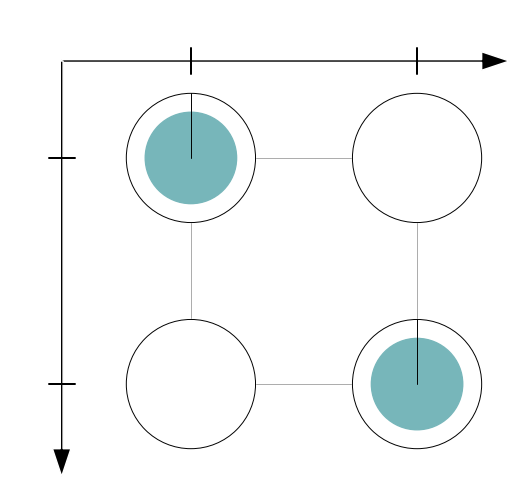
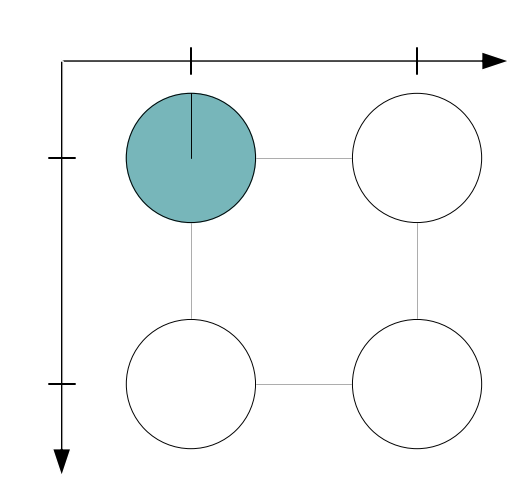
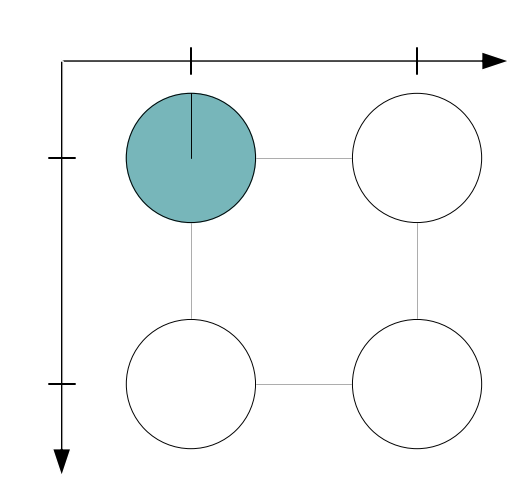
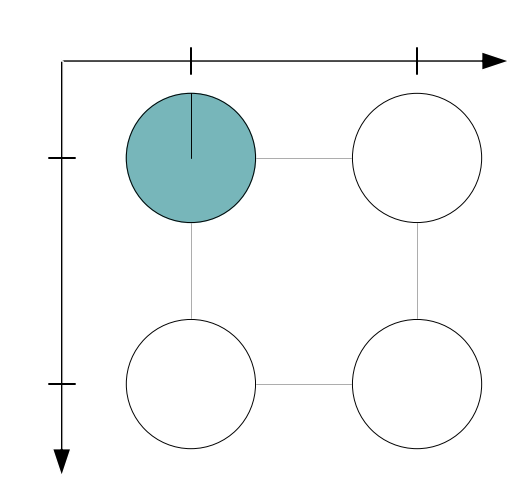

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import base64
from IPython.display import display, HTML

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Statevector

# Custom Package Imports (Needed for DCN Visualization)
from qc_education_package import Simulator, DimensionalCircleNotation

def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', transparent=True)
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

def latex_to_html(latex_obj):
    return latex_obj.data.replace('$$', '')

# --- TODO: STUDENT WORK SECTION ---
def create_bell_circuit(index):
    """
    Returns a Qiskit QuantumCircuit prepared in one of the 4 Bell states.
    index 0: Phi+ (|00> + |11>)
    index 1: Phi- (|00> - |11>)
    index 2: Psi+ (|01> + |10>)
    index 3: Psi- (|01> - |10>)
    """
    # Initialize a generic quantum circuit with 2 qubits
    qc = QuantumCircuit(2)

    if index == 0: # Phi+
        qc.h(0)      # Hadamard on qubit 0
        qc.cx(0, 1)  # CNOT with control 0, target 1

    elif index == 1: # Phi-
        # TODO: Implement circuit for Phi-
        pass

    elif index == 2: # Psi+
        # TODO: Implement circuit for Psi+
        pass

    elif index == 3: # Psi-
        # TODO: Implement circuit for Psi-
        pass

    return qc

# --- TABLE GENERATION (Do not modify) ---
bell_labels = [
    r"|\Phi^+\rangle",
    r"|\Phi^-\rangle",
    r"|\Psi^+\rangle",
    r"|\Psi^-\rangle"
]

html_table = """
<style>
    table.bell {width: 100%; border-collapse: collapse; text-align: center;}
    table.bell th {padding: 10px; border: 1px solid #ddd;}
    table.bell td {padding: 10px; border: 1px solid #ddd; vertical-align: middle;}
</style>
<table class="bell">
    <tr>
        <th>State Name</th>
        <th>Mathematical Vector</th>
        <th>Dimensional Circle Notation</th>
    </tr>
"""

for i in range(4):
    # 1. Get Qiskit Circuit from Student Function
    qc = create_bell_circuit(i)

    # 2. Convert Circuit to Statevector (for Math & Vis)
    # Statevector.from_instruction runs the circuit mathematically
    sv = Statevector.from_instruction(qc)

    # 3. Generate LaTeX
    latex_obj = array_to_latex(sv, prefix=f"{bell_labels[i]} = ")
    math_str = f"$${latex_to_html(latex_obj)}$$"

    # 4. Generate DCN Image
    # BRIDGE: We must move data from Qiskit to the custom Simulator for DCN to work
    sim_for_vis = Simulator(2)
    sim_for_vis.writeComplex(sv.data) # Load Qiskit's raw data into custom sim

    dcn = DimensionalCircleNotation(sim_for_vis)
    b64_dcn = dcn.exportBase64(formatStr="png")

    # 5. Add Row
    html_table += f"""
    <tr>
        <td><b>$${bell_labels[i]}$$</b></td>
        <td>{math_str}</td>
        <td><img src="data:image/png;base64,{b64_dcn}" width="250"></td>
    </tr>
    """

html_table += "</table>"
display(HTML(html_table))

plt.close('all')

# 4.5. Conclusion and Outlook

In this notebook, we have explored the concept of **entanglement**, a fundamental feature of quantum mechanics that distinguishes it from classical physics.

We learned that:
1.  **Multi-Qubit Systems** are described by the tensor product of individual states.
2.  **Interaction Gates** like the CNOT allow qubits to influence each other, creating correlations that cannot be described independently.
3.  **Bell States** are maximally entangled states where the measurement of one qubit instantly determines the state of the other, regardless of distance.
4.  **Separability** is the mathematical test for entanglement: if a state cannot be factored into a product of individual qubit states ($|\psi\rangle \neq |\psi_A\rangle \otimes |\psi_B\rangle$), it is entangled.

### The Power of Entanglement
Entanglement is not just a mathematical curiosity; it is the fuel for quantum advantage. In the upcoming notebooks, we will use the Bell states we created here to perform tasks that are impossible in the classical world:

* **Superdense Coding:** Transmitting two bits of classical information by sending only one qubit.
* **The Bell Experiment:** Proving that nature is not governed by "local hidden variables" (Einstein was wrong!).
* **The E91 Protocol:** Using entanglement to generate perfectly secure cryptographic keys.
* **Quantum Teleportation:** Transmitting a quantum state to a distant location without moving physical matter.

Beyond communication and computing, the use-cases of entanglement are vast. For instance, in **Quantum Sensing**, entangled particles can be used to measure physical quantities (like magnetic fields or gravitational waves) with precision that beats both classical limits and the "standard quantum limit" of non-interacting particles.



As we move forward, remember that entanglement is the resource that binds the quantum universe together.

References

[1] Just, B. (2023). Quantum computing compact (Vol. 1). Springer, Berlin, Germany.

[2] Bley, J., Rexigel, E., Arias, A., Longen, N., Krupp, L., Kiefer-Emmanouilidis, M., Lukowicz, P., Donhauser, A., Küchemann, S., Kuhn, J., & Widera, A. (2024). Visualizing entanglement in multiqubit systems. Physical Review Research, **6**(2), 023077.